# Знакомство с рекуррентной нейронной сетью

Практическая работа № 2 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Текста задания в СДО нет. Беру стандартное содержание: обучить
рекуррентную сеть на последовательностях, сравнить её с простыми моделями, показать графики
обучения и объяснить, зачем нужна рекуррентность. В лабораторной работе № 2 рекуррентная сеть
уже применялась к текстам, поэтому здесь беру вторую типовую задачу, прогноз временного ряда.

**Данные.** Ежедневная минимальная температура в Мельбурне за 1981–1990 годы: 3650 значений.
Набор открытый и маленький, поэтому работа воспроизводится за пару минут.

**Задача.** По температуре за последние 30 дней предсказать температуру на следующий день.

**Что с чем сравниваю:**
1. Наивный прогноз: завтра будет как сегодня. Это базовый уровень, который обязана обогнать любая модель.
2. Линейная регрессия по тем же 30 дням.
3. Рекуррентная сеть LSTM.

**План работы:**
1. Загрузка ряда и разведочный анализ.
2. Нарезка на окна и разбиение по времени.
3. Наивный прогноз и линейная регрессия.
4. Сеть LSTM.
5. Сравнение по MAE, RMSE и R², разбор ошибок.

## 0. Библиотеки и настройки

In [1]:
import os
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Устройство:', device)


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

Устройство: mps


## 1. Временной ряд

In [2]:
os.makedirs('data', exist_ok=True)
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
path = 'data/daily-min-temperatures.csv'
if not os.path.exists(path):
    urllib.request.urlretrieve(URL, path)

df = pd.read_csv(path, parse_dates=['Date'])
df = df.set_index('Date').sort_index()
print('Значений:', len(df), 'с', df.index.min().date(), 'по', df.index.max().date())
print(df['Temp'].describe().round(2).to_dict())
print('Пропущенных дней:', int(pd.date_range(df.index.min(), df.index.max()).difference(df.index).size))
df.head(3)

Значений: 3650 с 1981-01-01 по 1990-12-31
{'count': 3650.0, 'mean': 11.18, 'std': 4.07, 'min': 0.0, '25%': 8.3, '50%': 11.0, '75%': 14.0, 'max': 26.3}
Пропущенных дней: 2


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8


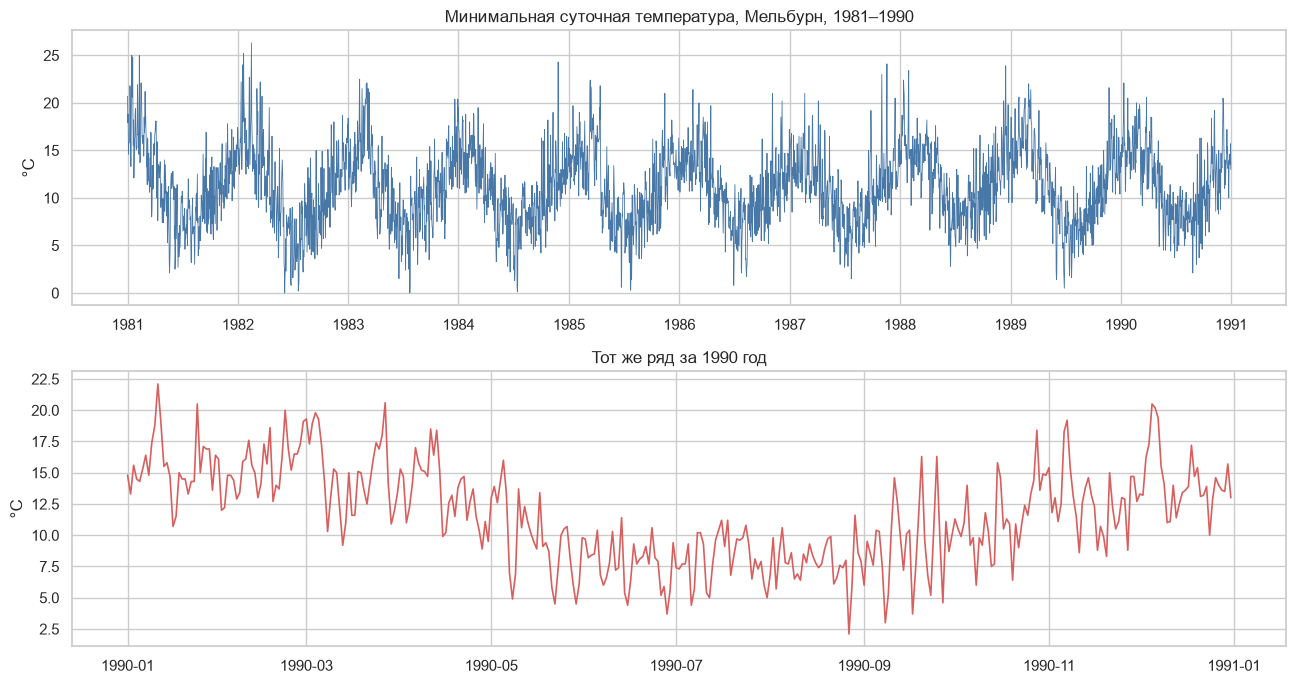

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
axes[0].plot(df.index, df['Temp'], linewidth=0.6, color='#4878a8')
axes[0].set_title('Минимальная суточная температура, Мельбурн, 1981–1990')
axes[0].set_ylabel('°C')

year = df.loc['1990']
axes[1].plot(year.index, year['Temp'], linewidth=1.2, color='#d95f5f')
axes[1].set_title('Тот же ряд за 1990 год')
axes[1].set_ylabel('°C')
fig.tight_layout()
save_fig('01_series.png')
plt.show()

**Рисунок 1 — Временной ряд целиком и за один год**

Ряд колеблется с годовым периодом и без заметного тренда за десять лет: в австралийское лето (январь и февраль) минимальная температура около 15 °C, в зимние июнь и июль около 7 °C.

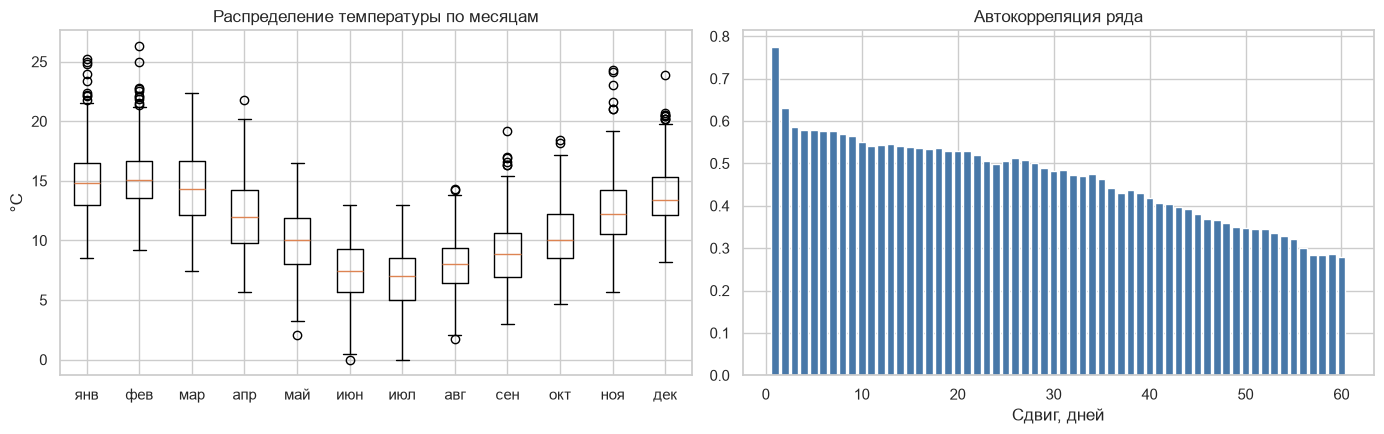

Автокорреляция: лаг 1 = 0.775 , лаг 7 = 0.576 , лаг 30 = 0.483


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
by_month = [df[df.index.month == m]['Temp'].values for m in range(1, 13)]
axes[0].boxplot(by_month, tick_labels=['янв', 'фев', 'мар', 'апр', 'май', 'июн',
                                       'июл', 'авг', 'сен', 'окт', 'ноя', 'дек'])
axes[0].set_title('Распределение температуры по месяцам')
axes[0].set_ylabel('°C')

lags = range(1, 61)
acf = [df['Temp'].autocorr(lag=l) for l in lags]
axes[1].bar(list(lags), acf, color='#4878a8')
axes[1].set_title('Автокорреляция ряда')
axes[1].set_xlabel('Сдвиг, дней')
fig.tight_layout()
save_fig('02_seasonality.png')
plt.show()

print('Автокорреляция: лаг 1 =', round(acf[0], 3), ', лаг 7 =', round(acf[6], 3),
      ', лаг 30 =', round(acf[29], 3))

**Рисунок 2 — Сезонность и автокорреляция ряда**

Годовая сезонность видна по месяцам, а автокорреляция падает с 0,775 на сдвиге в один день до 0,576 на неделе и 0,483 на месяце, то есть вчерашний день предсказывает завтрашний лучше всего.

## 2. Нарезка на окна и разбиение

Сеть учится на парах «30 дней подряд → следующий день». Такая нарезка превращает ряд
в обычную обучающую выборку, но с важным ограничением: разбивать её случайно нельзя.
Если перемешать окна, в обучение попадут дни из будущего относительно тестовых,
и оценка окажется завышенной. Поэтому разбиение строго по времени: первые 70 % дней
на обучение, следующие 15 % на валидацию, последние 15 % на тест.

Масштабирование тоже считается только по обучающей части: вычитаю среднее и делю
на стандартное отклонение обучающего отрезка.

In [5]:
WINDOW = 30
values = df['Temp'].values.astype(np.float32)

n = len(values)
i_train, i_val = int(n * 0.70), int(n * 0.85)
mean, std = values[:i_train].mean(), values[:i_train].std()
scaled = (values - mean) / std
print(f'Среднее обучающей части {mean:.2f} °C, отклонение {std:.2f} °C')


def make_windows(series, start, end):
    """Окна длиной WINDOW и следующее за ними значение."""
    X, y, idx = [], [], []
    for t in range(max(start, WINDOW), end):
        X.append(series[t - WINDOW:t])
        y.append(series[t])
        idx.append(t)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(idx)


X_train, y_train, _ = make_windows(scaled, 0, i_train)
X_val, y_val, _ = make_windows(scaled, i_train, i_val)
X_test, y_test, idx_test = make_windows(scaled, i_val, n)

print(f'Окон: обучение {len(X_train)}, валидация {len(X_val)}, тест {len(X_test)}')
print('Тестовый период:', df.index[idx_test[0]].date(), '—', df.index[idx_test[-1]].date())

Среднее обучающей части 10.98 °C, отклонение 4.09 °C
Окон: обучение 2525, валидация 547, тест 548
Тестовый период: 1989-07-02 — 1990-12-31


## 3. Базовые модели

**Наивный прогноз.** Температура завтра равна температуре сегодня. Для суточных температур
это сильный базовый уровень: соседние дни похожи, автокорреляция на лаге 1 около 0,77.

**Линейная регрессия.** Взвешенная сумма тех же 30 значений окна. Модель учит веса,
но не умеет хранить состояние и не отличает один день от другого по порядку внутри окна.

In [6]:
def metrics(name, y_true_s, y_pred_s):
    """Метрики в градусах: возвращаю масштаб обратно."""
    yt = y_true_s * std + mean
    yp = y_pred_s * std + mean
    return {
        'Модель': name,
        'MAE, °C': mean_absolute_error(yt, yp),
        'RMSE, °C': np.sqrt(mean_squared_error(yt, yp)),
        'R²': r2_score(yt, yp),
    }


results, preds = [], {}

naive = X_test[:, -1]
preds['Наивный прогноз'] = naive
results.append(metrics('Наивный прогноз', y_test, naive))

lin = LinearRegression().fit(X_train, y_train)
preds['Линейная регрессия'] = lin.predict(X_test)
results.append(metrics('Линейная регрессия', y_test, preds['Линейная регрессия']))

pd.DataFrame(results).set_index('Модель').round(3)

,"MAE, °C","RMSE, °C",R²
Модель,,,
Наивный прогноз,2.036,2.572,0.565
Линейная регрессия,1.745,2.239,0.670


## 4. Рекуррентная сеть LSTM

Рекуррентная сеть обрабатывает окно по одному дню за шаг и хранит состояние, в которое
записывает то, что уже прочитала. Благодаря состоянию сеть может уловить не только уровень
температуры, но и её динамику: растёт ряд последние дни или падает.

LSTM это рекуррентная ячейка с тремя вентилями: забывания, входным и выходным. Вентили
управляют состоянием, поэтому сеть не забывает начало окна и не страдает от затухания градиента.

Архитектура: вход из одного числа на шаг, LSTM с 32 скрытыми нейронами, линейный слой
на один выход. Прогноз берётся из последнего состояния.

In [7]:
class LSTMForecast(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, (h, c) = self.lstm(x.unsqueeze(-1))
        return self.fc(h[-1]).squeeze(1)


def loaders(X, y, batch=64, shuffle=False):
    return DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)), batch_size=batch, shuffle=shuffle)


train_dl = loaders(X_train, y_train, shuffle=True)
val_dl = loaders(X_val, y_val)
test_dl = loaders(X_test, y_test)

model = LSTMForecast().to(device)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {'train': [], 'val': []}
EPOCHS = 30
best_loss, best_state = float('inf'), None

t0 = time.time()
for ep in range(1, EPOCHS + 1):
    for mode, dl in [('train', train_dl), ('val', val_dl)]:
        model.train(mode == 'train')
        total, count = 0.0, 0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            with torch.set_grad_enabled(mode == 'train'):
                out = model(xb)
                loss = criterion(out, yb)
            if mode == 'train':
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * yb.size(0)
            count += yb.size(0)
        history[mode].append(total / count)
    if history['val'][-1] < best_loss:
        best_loss = history['val'][-1]
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    if ep % 5 == 0 or ep == 1:
        print(f"эпоха {ep:2}: MSE обучение {history['train'][-1]:.4f}, валидация {history['val'][-1]:.4f}")
model.load_state_dict(best_state)
print(f'обучение заняло {time.time() - t0:.0f} с, лучшая MSE на валидации {best_loss:.4f}')

Параметров: 4,513


эпоха  1: MSE обучение 0.8068, валидация 0.5804


эпоха  5: MSE обучение 0.4337, валидация 0.4047


эпоха 10: MSE обучение 0.3901, валидация 0.3491


эпоха 15: MSE обучение 0.3664, валидация 0.3282


эпоха 20: MSE обучение 0.3615, валидация 0.3230


эпоха 25: MSE обучение 0.3624, валидация 0.3217


эпоха 30: MSE обучение 0.3605, валидация 0.3281
обучение заняло 8 с, лучшая MSE на валидации 0.3210


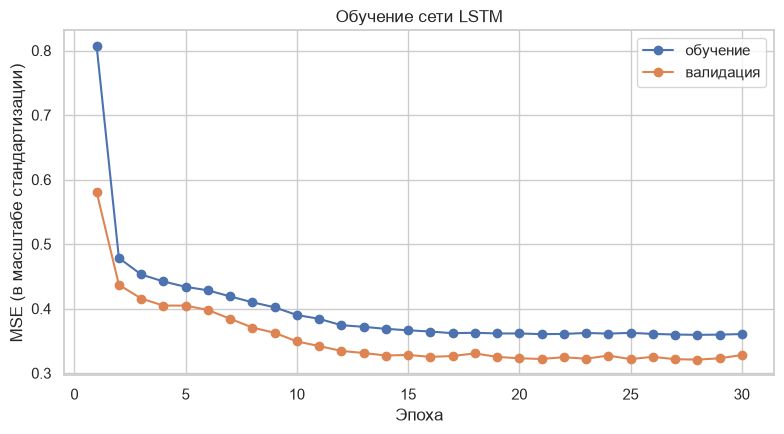

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ep = range(1, EPOCHS + 1)
ax.plot(ep, history['train'], 'o-', label='обучение')
ax.plot(ep, history['val'], 'o-', label='валидация')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE (в масштабе стандартизации)')
ax.set_title('Обучение сети LSTM')
ax.legend()
fig.tight_layout()
save_fig('03_lstm_training.png')
plt.show()

**Рисунок 3 — Кривые обучения сети LSTM**

Ошибка на валидации падает с 0,580 до 0,321 за первые двадцать эпох и дальше не улучшается, разрыв с обучающей кривой небольшой, переобучения нет.

In [9]:
model.eval()
out = []
with torch.no_grad():
    for xb, _ in test_dl:
        out.append(model(xb.to(device)).cpu().numpy())
preds['LSTM'] = np.concatenate(out)
results.append(metrics('LSTM', y_test, preds['LSTM']))

res_df = pd.DataFrame(results).set_index('Модель').sort_values('MAE, °C')
res_df.round(3)

,"MAE, °C","RMSE, °C",R²
Модель,,,
LSTM,1.735,2.221,0.675
Линейная регрессия,1.745,2.239,0.670
Наивный прогноз,2.036,2.572,0.565


## 5. Сравнение моделей

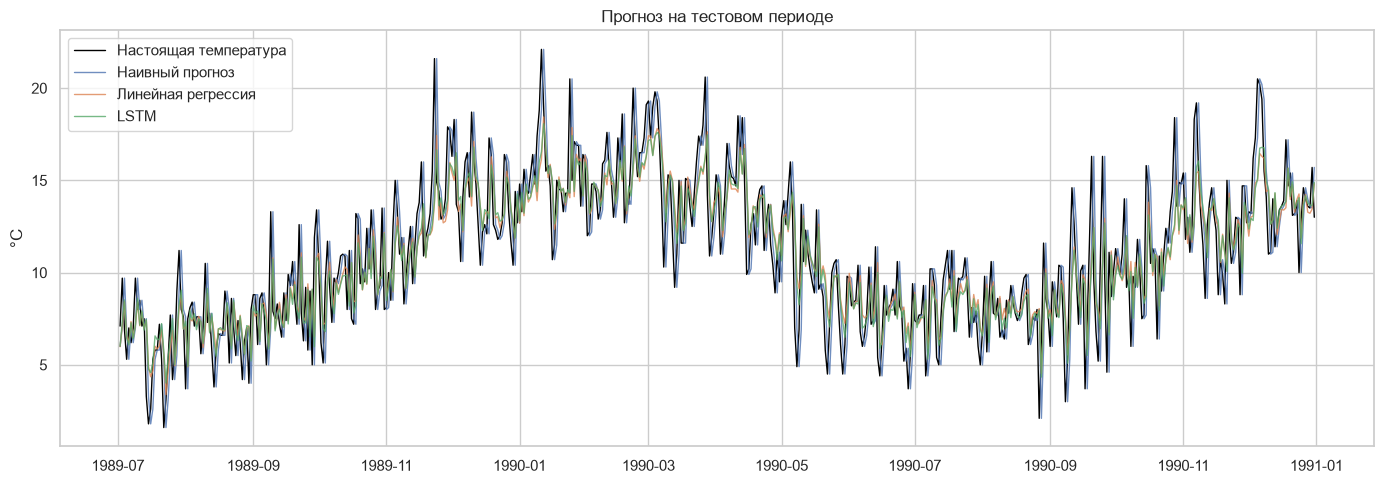

In [10]:
dates = df.index[idx_test]
true_deg = y_test * std + mean

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, true_deg, label='Настоящая температура', color='black', linewidth=1)
for name, color in [('Наивный прогноз', '#b0b0b0'), ('Линейная регрессия', '#d95f5f'), ('LSTM', '#4878a8')]:
    ax.plot(dates, preds[name] * std + mean, label=name, linewidth=1, alpha=0.8)
ax.set_ylabel('°C')
ax.set_title('Прогноз на тестовом периоде')
ax.legend()
fig.tight_layout()
save_fig('04_forecast.png')
plt.show()

**Рисунок 4 — Прогноз моделей на тестовом периоде**

Все три модели повторяют годовой ход температуры, но резкие однодневные скачки не угадывает ни одна: прогнозы сглажены по сравнению с фактом.

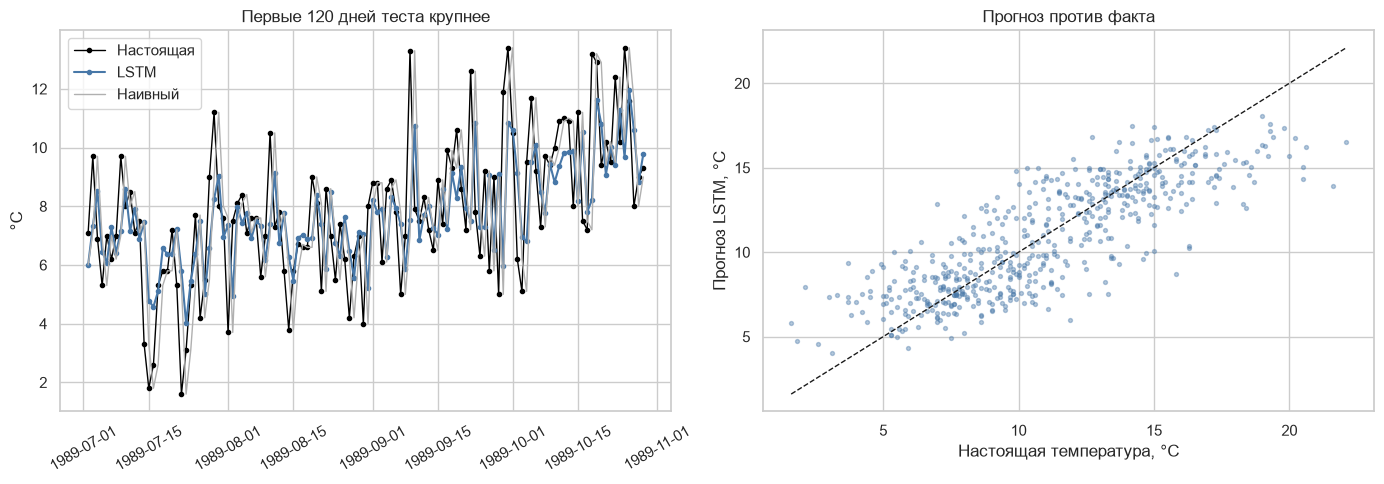

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sl = slice(0, 120)
axes[0].plot(dates[sl], true_deg[sl], 'o-', markersize=3, label='Настоящая', color='black', linewidth=1)
axes[0].plot(dates[sl], (preds['LSTM'] * std + mean)[sl], 'o-', markersize=3, label='LSTM', color='#4878a8')
axes[0].plot(dates[sl], (preds['Наивный прогноз'] * std + mean)[sl], linewidth=1,
             label='Наивный', color='#b0b0b0')
axes[0].set_title('Первые 120 дней теста крупнее')
axes[0].set_ylabel('°C')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

axes[1].scatter(true_deg, preds['LSTM'] * std + mean, s=8, alpha=0.4, color='#4878a8')
lims = [true_deg.min(), true_deg.max()]
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('Настоящая температура, °C')
axes[1].set_ylabel('Прогноз LSTM, °C')
axes[1].set_title('Прогноз против факта')
fig.tight_layout()
save_fig('05_detail.png')
plt.show()

**Рисунок 5 — Прогноз крупным планом и сравнение с фактом**

На увеличенном отрезке видно, что наивный прогноз просто повторяет вчерашний день со сдвигом, а LSTM сглаживает колебания; на диаграмме рассеяния точки вытянуты вдоль диагонали, но с заметным разбросом.

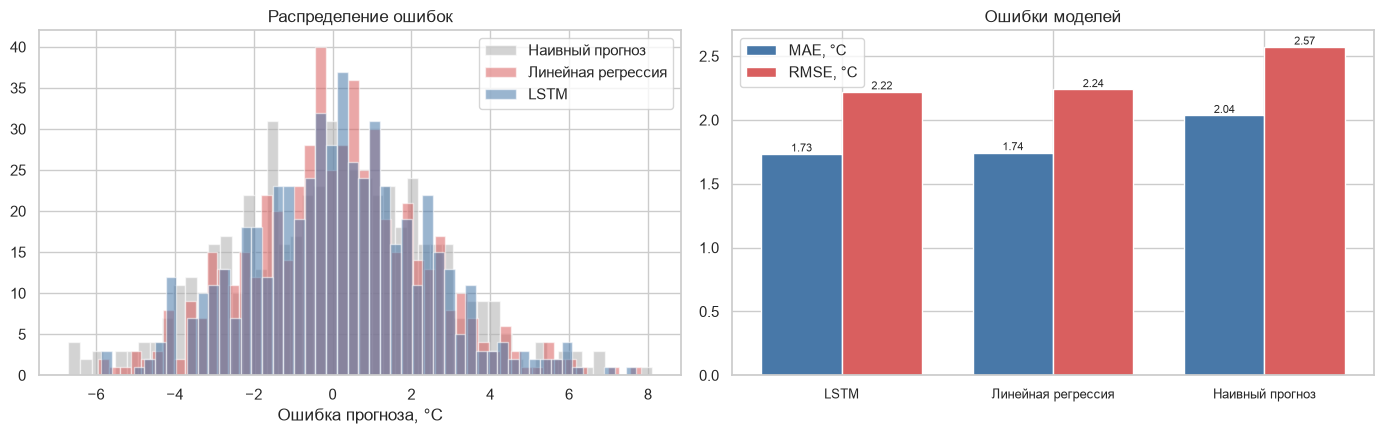

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, color in [('Наивный прогноз', '#b0b0b0'), ('Линейная регрессия', '#d95f5f'), ('LSTM', '#4878a8')]:
    resid = true_deg - (preds[name] * std + mean)
    axes[0].hist(resid, bins=50, alpha=0.55, label=name, color=color)
axes[0].set_xlabel('Ошибка прогноза, °C')
axes[0].set_title('Распределение ошибок')
axes[0].legend()

x = np.arange(len(res_df))
width = 0.38
b1 = axes[1].bar(x - width / 2, res_df['MAE, °C'], width, label='MAE, °C', color='#4878a8')
b2 = axes[1].bar(x + width / 2, res_df['RMSE, °C'], width, label='RMSE, °C', color='#d95f5f')
axes[1].bar_label(b1, fmt='%.2f', fontsize=8)
axes[1].bar_label(b2, fmt='%.2f', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(res_df.index, fontsize=9)
axes[1].set_title('Ошибки моделей')
axes[1].legend()
fig.tight_layout()
save_fig('06_errors.png')
plt.show()

**Рисунок 6 — Распределение ошибок и сравнение моделей**

Ошибки всех моделей распределены почти симметрично вокруг нуля, а по MAE и RMSE LSTM (1,735 и 2,221 °C) и линейная регрессия (1,745 и 2,239 °C) идут вровень, наивный прогноз отстаёт на 0,3 °C.

In [13]:
# где LSTM ошибается сильнее всего
resid = np.abs(true_deg - (preds['LSTM'] * std + mean))
worst = np.argsort(-resid)[:5]
print('Худшие прогнозы LSTM:')
for k in worst:
    print(f'  {dates[k].date()}: факт {true_deg[k]:.1f} °C, прогноз '
          f'{(preds["LSTM"][k] * std + mean):.1f} °C, ошибка {resid[k]:.1f} °C')
print(f'\nСредняя ошибка LSTM {resid.mean():.2f} °C, у наивного прогноза '
      f'{np.abs(true_deg - (preds["Наивный прогноз"] * std + mean)).mean():.2f} °C')

Худшие прогнозы LSTM:
  1989-11-23: факт 21.6 °C, прогноз 13.9 °C, ошибка 7.7 °C
  1990-10-15: факт 15.8 °C, прогноз 8.7 °C, ошибка 7.1 °C
  1990-01-24: факт 20.5 °C, прогноз 14.3 °C, ошибка 6.2 °C
  1990-09-20: факт 16.3 °C, прогноз 10.3 °C, ошибка 6.0 °C
  1990-09-25: факт 16.3 °C, прогноз 10.4 °C, ошибка 5.9 °C

Средняя ошибка LSTM 1.73 °C, у наивного прогноза 2.04 °C


## 6. Выводы

1. **Задача и данные.** Ряд из 3650 суточных минимальных температур Мельбурна за 1981–1990 годы.
   По окну из 30 дней предсказывается следующий день. Разбиение строго по времени:
   2525 окон на обучение, 547 на валидацию, 548 на тест (июль 1989 года и весь 1990 год).

2. **Результаты на тесте:**

   | Модель | MAE, °C | RMSE, °C | R² |
   |---|---|---|---|
   | LSTM | 1,735 | 2,221 | 0,675 |
   | Линейная регрессия | 1,745 | 2,239 | 0,670 |
   | Наивный прогноз | 2,036 | 2,572 | 0,565 |

3. **Рекуррентная сеть обогнала наивный прогноз на 0,30 °C по MAE,** но линейную регрессию
   всего на 0,01 °C. Честный вывод: на суточных температурах зависимость от последних дней
   почти линейная, и запоминать порядок внутри окна почти нечего. Рекуррентность окупается там,
   где важен порядок и длинные зависимости: в текстах, речи, ряде с переключением режимов.

4. **Сеть очень компактная:** 4513 параметров, обучение 30 эпох за 8 секунд.
   Линейная регрессия по 30 признакам обучается мгновенно и даёт почти то же самое,
   поэтому для этой задачи она предпочтительнее по соотношению сложности и качества.

5. **Где модель ошибается.** Худшие прогнозы приходятся на резкие потепления:
   23 ноября 1989 года факт 21,6 °C, прогноз 13,9 °C, ошибка 7,7 °C. Такие скачки вызваны
   сменой воздушной массы, а в ряде температур этой информации нет.

6. **Почему разбиение по времени, а не случайное.** При случайном перемешивании окон в обучение
   попали бы дни из будущего относительно тестовых, соседние окна перекрываются на 29 днях,
   и оценка оказалась бы завышенной. Для временных рядов это грубая ошибка методики.

7. **Что улучшило бы прогноз:** добавить признаки календаря (день года, месяц), прогноз на
   несколько дней вперёд с честной оценкой по горизонту, внешние данные (давление, влажность),
   двунаправленную или многослойную сеть при большем объёме данных.